### Correlation and Variable Relationships
Introduction

Correlation helps us measure how strongly two variables are related.

In the previous lesson, we observed:

Property prices are right-skewed.
Larger properties generally have higher prices.
The relationship between area and price varies by state.

In this lesson, we will:

Measure the strength of the area–price relationship.
Use a correlation coefficient to quantify relationships.
Visualize relationships between multiple variables using a heatmap.
Compare the relationship across different states.

Research Question:
Is property size (area_m2) a stronger predictor of price than location?

<!-- from IPython.display import Markdown, display -->

* display(Markdown("[Open Shared Chat in ChatGPT](https://chatgpt.com/s/w_6abfe9140d188191aab38d0837555406)"))

#### 1. Setup and Data Loading

We import our libraries and load the clean dataset. This lesson introduces
`seaborn` (aliased as `sns`), a statistical visualization library that makes
heatmaps effortless.

**Code Task 1.3.1.1**: Import `pandas`, `matplotlib.pyplot`, and `seaborn`,
define `data_path`, and load the data.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the path to the clean CSV file
# data_path = "data/brasil-real-estate-1.csv"
data_path = "./data/mexico-real-estate-combined-clean.csv"
# Load the data
data = pd.read_csv(data_path)

# Verify the load
print(f"Dimensions: {data.shape[0]} rows and {data.shape[1]} columns.")
data.head()

Dimensions: 1736 rows and 6 columns.


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12833 entries, 0 to 12832
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  12833 non-null  str    
 1   state          12833 non-null  str    
 2   region         12833 non-null  str    
 3   lat            12833 non-null  float64
 4   lon            12833 non-null  float64
 5   area_m2        11293 non-null  float64
 6   price_brl      12833 non-null  float64
dtypes: float64(4), str(3)
memory usage: 1.0 MB


In [26]:
# Replace any '$' or ',' using regex
data["price_usd"] = (
    data["price_usd"]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True)
    .astype(float)
)

In [30]:
data.head()
# data.info()

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,187230.85
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,81133.37
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,154465.45
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,146013.20
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,101416.71


### 2. Pearson Correlation Coefficient

Pearson correlation (r) tells us how strongly two variables have a linear relationship.

2.1 Basic Idea

The value of r is always between -1 and +1:

Positive r → both variables tend to increase together.
Negative r → one increases while the other decreases.
r near 0 → little or no linear relationship.

* display(Markdown("[Open Shared Chat in ChatGPT](https://chatgpt.com/s/w_6abfe9140d188191aab38d0837555406)"))

#### 2.2 The Math

$$r_{XY} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2}\,\sqrt{\sum(y_i - \bar{y})^2}}$$

**Numerator** — $\sum(x_i - \bar{x})(y_i - \bar{y})$:

For each observation $i$, the product $(x_i - \bar{x})(y_i - \bar{y})$ is:

- **Positive** when both X and Y are simultaneously above their averages, OR both
  below their averages (they move together).
- **Negative** when X is above its average while Y is below (they move in opposite
  directions).

Summing across all observations gives a measure of the *overall tendency* to move
together.

**Denominator** — the scaling factor:

$$\sqrt{\sum(x_i - \bar{x})^2} \cdot \sqrt{\sum(y_i - \bar{y})^2}$$

This is the product of the standard deviations (without the $\frac{1}{n-1}$ factor)
of X and Y. Dividing by it *normalizes* the numerator, ensuring $r$ always falls
between -1 and +1 regardless of the units or scale of X and Y.

| `r` Value      | Relationship                  |
| -------------- | ----------------------------- |
| `+1`           | Perfect positive              |
| `0.7 to 1.0`   | Strong positive               |
| `0.4 to 0.7`   | Moderate positive             |
| `0.1 to 0.4`   | Weak positive                 |
| `-0.1 to +0.1` | Little/no linear relationship |
| `-0.4 to -0.1` | Weak negative                 |
| `-0.7 to -0.4` | Moderate negative             |
| `-1`           | Perfect negative              |

>Note: These are general guidelines. The meaning of a correlation depends on the data and context.


#### 2.3 How Pearson r Works

For each value:

Find how far X is from its average.
Find how far Y is from its average.
Compare their movements.
Combine and normalize the results.

This produces a value between -1 and +1.

#### 2.4 Three Important Points

1. Correlation only measures linear relationships.
A curved relationship may have a low Pearson r even when the variables are clearly related.

2. Correlation does not mean causation.
If area and price are correlated, it does not prove that area causes the price increase. Other factors, such as location, may affect both.

3. Outliers and small samples can affect r.
A few extreme values or very few observations can produce misleading correlations.

#### 2.5 Correlation in Pandas

| Method                    | Purpose                                  |
| ------------------------- | ---------------------------------------- |
| `series_a.corr(series_b)` | Correlation between two columns          |
| `df.corr()`               | Correlations between all numeric columns |

By default, Pandas uses Pearson correlation.

**Code Task 1.3.2.1**: Compute the Pearson correlation between `"area_m2"` and
`"price_usd"` for the full national dataset.


Example:

data["area_m2"].corr(data["price_usd"])

This gives us a numerical measure of how strongly property size and price are linearly related.

In [34]:
# Calculate correlation between 'area_m2' and 'price_usd'
corr_price_area = (
    data['area_m2']
    .corr(data['price_usd'])
)

print(f"The correlation between Area and Price is: {corr_price_area:.2f}")

The correlation between Area and Price is: 0.59


#### What Does `r ≈ 0.59` Mean?

A Pearson correlation of **0.59** means there is a **moderate positive linear relationship** between property area and price.

### Key Meaning

* `r = 0.59`
* `r² ≈ 0.35`
* About **35% of price variation is associated with area**.
* The remaining **65% is related to other factors**, such as location, property type, condition, and amenities.

### What It Tells Us

* Larger properties generally tend to have higher prices.
* Area is **useful for predicting price**, but it is not enough by itself.
* Individual predictions can still have large errors.

### What `r = 0.59` Does NOT Tell Us

**1. Same relationship everywhere?**
No. The correlation may be strong in some states and weak in others.

**2. Causation?**
No. Correlation does not prove that increasing area causes a higher price. Location and other factors may affect both.

**3. Relationship is perfectly linear?**
No. Pearson correlation measures **linear relationships**. A curved relationship may not be represented well by `r`.

> **Remember:** `r = 0.59` tells us that area and price have a moderate positive linear relationship, but it does not explain the whole story.


## Reading the National Correlation

A national correlation of **`r ≈ 0.59`** shows a **moderate positive relationship** between area and price.

### What It Means

* Larger properties generally have higher prices.
* The wide scatter in the data explains why `r` is not close to `1.0`.

### What `0.59` Cannot Tell Us

* Whether the relationship is the same across all states.
* Whether the relationship is truly linear.
* Whether **area or location** is more important for price.

> **Key Point:** A single national correlation is only a starting point. We need to examine other variables and different groups.

---

# 3. Correlation Matrix and Heatmap

A **correlation matrix** shows the Pearson correlation between **every pair of numerical variables**.

For example, with:

* `area_m2`
* `price_usd`
* `lat`
* `lon`

we get a **4 × 4 correlation matrix**.

### Important Points

* The diagonal is always **1.0** because each variable is perfectly correlated with itself.
* The matrix is **symmetric**: `r(A,B) = r(B,A)`.
* We usually need to examine only one half of the matrix.

### When to Use It

Use a correlation matrix to:

* Quickly explore relationships between numerical variables.
* Find possible predictors for a model.
* Identify highly correlated predictors.
* Check whether expected relationships exist.

### Limitations

A correlation matrix:

* May miss **curved/non-linear relationships**.
* Works directly with **numerical variables**, not categorical variables.
* Shows **association, not causation**.

### Code Task 1.3.3.1

Calculate the complete correlation matrix:

```python
correlation_matrix = data.corr()
print(correlation_matrix)
```

**Next:** We can visualize this matrix using a **heatmap**.


In [40]:
# Select only numerical columns
# Compute the correlation matrix
corr_matrix = (
    data
    .select_dtypes("number") # to select the numeric data only
    .corr()
)

corr_matrix

,lat,lon,area_m2,price_usd
lat,1.000000,-0.480231,0.082314,-0.085868
lon,-0.480231,1.000000,0.095522,0.032815
area_m2,0.082314,0.095522,1.000000,0.585518
price_usd,-0.085868,0.032815,0.585518,1.000000


#### 3.2 Visualizing Correlation with a Heatmap

A **heatmap** uses colors to show correlation values, making relationships easier to understand than a table of numbers.

### How to Read It

* **Red** → Positive correlation
* **Blue** → Negative correlation
* **White** → Little or no correlation
* **Darker color** → Stronger relationship

### Important `seaborn.heatmap()` Parameters

| Parameter         | Purpose                                  |
| ----------------- | ---------------------------------------- |
| `annot=True`      | Shows the correlation value in each cell |
| `cmap="coolwarm"` | Uses colors for positive/negative values |
| `ax=ax`           | Places the heatmap on a Matplotlib axes  |
| `vmin=-1, vmax=1` | Keeps the scale between -1 and +1        |

**Code 1.3.3.1** — Heatmap:

> **Key Point:** A heatmap lets us quickly identify which variables have strong, weak, positive, or negative relationships.


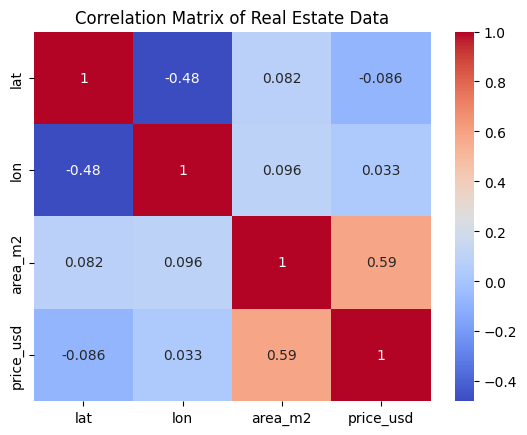

In [49]:
# Create a figure
fig, ax = plt.subplots()

# Create the heatmap using Seaborn
# annot=True adds the numbers to the boxes
# cmap="coolwarm" creates a nice Red (hot/positive) to Blue (cold/negative) spectrum
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", ax=ax)

ax.set_title("Correlation Matrix of Real Estate Data")
plt.show()

### Reading the Correlation Heatmap

Focus on the **`price_usd` row/column** to see how each variable relates to price.

### Key Findings

* **`area_m2` ↔ `price_usd` ≈ 0.59** → moderate positive relationship.
* **`lat` / `lon` ↔ `price_usd`** → weaker relationships.
* **Diagonal = 1.0** → every variable is perfectly correlated with itself.
* **`lat` ↔ `lon` ≈ -0.48** → a geographic pattern caused by Mexico's shape, not a property-price relationship.

> **Important:** Not every correlation is meaningful. Always ask whether the relationship makes sense in the real world.

### How to Read a Heatmap

1. **Check the labels** → identify the variables.
2. **Check the diagonal** → it should always be `1.0`.
3. **Find strong relationships** → look for strong colors and large `|r|` values.
4. **Read the numbers** → colors give an overview; numbers give precision.
5. **Investigate unexpected correlations** → they may be caused by data structure or geography.
6. **Check near-zero values** → little linear relationship does not always mean no relationship.

### Simpson's Paradox

The national `r = 0.59` combines data from different states. If the relationship between area and price varies greatly by state, the national correlation may **hide important local patterns**.

> **Key Point:** Always examine both the **overall relationship** and the **relationship within important groups**.

---

### 4. Segmented Correlations: Why Averages Can Mislead

The national `r = 0.59` is only a starting point.

Now we ask:

**Does the area–price relationship remain similar across all states, or does it change from state to state?**

If correlations vary significantly between states, the national value may not represent any particular state's housing market accurately.


In [50]:
(
    data
    .head()
)

,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


### 4.1 Correlation by State — Step by Step

We want to calculate the **area–price correlation separately for each state**.

### Steps

1. **Split** the data by `state`.
2. **Select** `area_m2` and `price_usd`.
3. **Calculate** correlation for each state.
4. **Combine** the results into one Series.

This is called the **Split → Apply → Combine** pattern.

### Step 1: Group by State

```python
grouped = data.groupby("state")[["area_m2", "price_usd"]]
```

### What Happens?

You will see something like:

```text
<pandas.core.groupby.generic.DataFrameGroupBy object>
```

This is **normal**.

The `groupby()` operation has only prepared the groups. It has **not calculated anything yet**.

Think of it as:

> **Group the data → Select the columns → Now tell pandas what to calculate.**

Next, we will apply `.corr()` to calculate the correlation for each state.


In [58]:
grouped = data.groupby("state")[["area_m2", "price_usd"]]
grouped.head()

,area_m2,price_usd
0,150.0,67965.56
1,186.0,63223.78
2,82.0,84298.37
3,150.0,94308.80
4,205.0,105191.37
...,...,...
1442,160.0,115937.75
1487,94.0,51118.00
1552,161.0,52633.79
1604,180.0,76413.51


## Apply Correlation to Each State

Now we calculate the correlation matrix for **each state**.

### Code 1.3.4.3

```python id="4n0x8m"
state_corr = grouped.corr()
```

### What Does It Produce?

For every state, Pandas creates a **2×2 correlation matrix**:

|             |        `area_m2` |      `price_usd` |
| ----------- | ---------------: | ---------------: |
| `area_m2`   |              1.0 | **Area–Price r** |
| `price_usd` | **Area–Price r** |              1.0 |

The output uses a **MultiIndex**:

* **Level 0:** State name
* **Level 1:** Variable name

### What We Need

We only need:

`area_m2 ↔ price_usd`

The `1.0` values are not useful because they represent a variable correlated with itself.

> **Key Point:** `.corr()` gives us a complete matrix for every state. Next, we will extract **only the area–price correlation** for each state.


In [61]:
cor = grouped.corr().head()

**Code 1.3.4.4** — `.iloc[:, 1]` — select only the `price_usd` column:

> 📌 **`.iloc` explained**
>
> - `iloc` stands for **integer location** — selection by position number, not by
>   label name.
> - `.iloc[:, 1]` means: "from all rows (`:`), give me only the column at index
>   position 1."
>
> In our 2×2 matrix, columns are `area_m2` (position 0) and `price_usd` (position 1).
> Selecting position 1 keeps only the `price_usd` column, reducing from 4 values
> per state to 2 values per state.
>
> **After this step**, you still have 2 rows per state:
> - `area_m2` row: the area-price correlation (what we want)
> - `price_usd` row: always 1.0 (trivial, must be removed)
>
> The next step (`.xs()`) extracts only the `area_m2` row from each state.


In [63]:
cor.iloc[:, 1].head(10)

state                         
Aguascalientes       area_m2      0.873437
                     price_usd    1.000000
Baja California      area_m2      0.658334
                     price_usd    1.000000
Baja California Sur  area_m2      0.880583
Name: price_usd, dtype: float64

**Code 1.3.4.5** — `.xs("area_m2", level=1)` — extract one correlation per state:

> 📌 **`.xs()` — cross-section through a MultiIndex**
>
> `.xs()` lets you "slice through" a MultiIndex at a specific level and value.
>
> - `"area_m2"` is the label we want to keep.
> - `level=1` tells pandas to look at the **inner** level of the index (the variable
>   name level, not the state level which is at level 0).
>
> **After this step**, you have exactly one correlation value per state — the
> `area_m2` ↔ `price_usd` Pearson r for that state's listings.
>
> The MultiIndex is gone; the result is a simple Series indexed by state name.
>
> **Try it yourself:** Replace `"area_m2"` with `"price_usd"` in the `.xs()` call
> and re-run. You should get a Series of 1.0 values — because `price_usd`
> correlated with itself is always 1. This confirms that `"area_m2"` is the row
> we actually want.


In [64]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()
    .iloc[:, 1]
    .xs("area_m2", level=1)
    .head() # <-- to only view the top 5 rows
)

state
Aguascalientes         0.873437
Baja California        0.658334
Baja California Sur    0.880583
Campeche               0.824161
Chiapas                0.755961
Name: price_usd, dtype: float64

**Code 1.3.4.6** — `.sort_values(ascending=False)` — rank states from strongest
to weakest area-price correlation:

> The default `ascending=True` would put the smallest values first (weakest or
> most negative correlations at the top). For this analysis, we want the strongest
> at the top — so we set `ascending=False`.
>
> **Try it yourself:** Change to `ascending=True` and re-run. The ranking reverses.
> Then revert before proceeding.


In [66]:
(
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()
    .iloc[:, 1]
    .xs("area_m2", level=1)
    .sort_values(ascending=True)
    .head() # <-- to only view the top 5 rows
)

state
Oaxaca                            -1.000000
Tabasco                            0.241284
Distrito Federal                   0.410704
Veracruz de Ignacio de la Llave    0.567469
Nuevo León                         0.578696
Name: price_usd, dtype: float64

**Code 1.3.4.7** — The complete chain. Now that we understand every step, we assemble the full pipeline:

In [67]:
# Calculate correlation by state

correlations_by_state = (
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()                          # Build correlation matrix per state
    .iloc[:, 1]                      # Keep only the price_usd column
    .xs("area_m2", level=1)          # Extract one correlation value per state
    .sort_values(ascending=False)    # Rank strongest to weakest
)

print(correlations_by_state.head(5))
print("\n... and the bottom 5 ...\n")
print(correlations_by_state.tail(5))

state
Zacatecas              1.000000
Colima                 0.988235
Sonora                 0.911524
Durango                0.909258
Baja California Sur    0.880583
Name: price_usd, dtype: float64

... and the bottom 5 ...

state
Nuevo León                         0.578696
Veracruz de Ignacio de la Llave    0.567469
Distrito Federal                   0.410704
Tabasco                            0.241284
Oaxaca                            -1.000000
Name: price_usd, dtype: float64


---
## Reading Correlation by State

State-level correlations show that the relationship between **area and price varies by state**.

### Key Findings

* **High `r` (≈ 0.8+)** → area has a strong linear relationship with price.
* **Low `r` (≈ 0 or below)** → area has a weak or no linear relationship with price.
* **Near ±1 with very small samples** → may be unreliable.

> **Important:** Always check the number of listings in each state. A correlation based on only a few properties can be misleading.

```python
data.groupby("state").size()
```

### Simpson's Paradox

The national `r ≈ 0.59` can hide major differences between states:

* **Nationally:** moderate positive relationship
* **Some states:** strong relationship
* **Other states:** weak relationship

The national value is not necessarily wrong; it is simply **incomplete**.

### Practical Steps

When subgroup correlations differ:

1. **Check sample sizes** before interpreting them.
2. **Check the direction** — do correlations change from positive to negative?
3. **Look for confounding factors**, such as location.
4. **Report both national and subgroup results.**
5. If necessary, use **separate models or interaction terms** for different states.

> **Key Lesson:** Never rely only on an overall average. Always examine important subgroups.

### Important Coding Note

Remove `.head()` from the final pipeline. Otherwise, you may accidentally keep only the first few states instead of calculating results for **all states**.

---

## 4.2 Correlation by Property Type

Now we ask:

**Do houses and apartments have the same area–price relationship?**

### Code Task 1.3.4.1

Calculate the area–price correlation grouped by:

```python
property_type
```

This will help us compare pricing patterns between different property types.


In [68]:
# Calculate correlation by property_type
correlations_by_prop = (
    data
    .groupby('property_type')   # groupby `"property_type"`
    [['area_m2', 'price_usd']]    # we select by the `"area_m2"` and `"price_usd"` columns
    .corr()
    .iloc[:, 1]
    .xs('area_m2', level=1) # extracts the `"area_m2"` correlation value from the inner index level.
)

print(correlations_by_prop)

property_type
apartment    0.519021
house        0.719280
Name: price_usd, dtype: float64
